In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
from sklearn.tree import plot_tree
from scipy import stats
from scipy.stats import norm
from sklearn import neighbors
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Cargar dataset directamente
# Cargar dataset directamente desde UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## Descripción de las variables

**Variables Cuantitativas Continuas**

- `fixed acidity` — acidez fija (ácido tartárico, g/L)
- `volatile acidity` — acidez volátil (ácido acético, g/L) — correlación negativa con calidad
- `citric acid` — ácido cítrico (g/L) — aporta frescura al vino
- `residual sugar` — azúcar residual tras la fermentación (g/L)
- `chlorides` — cloruros, sal en el vino (g/L)
- `free sulfur dioxide` — SO₂ libre, actúa como conservante (mg/L)
- `total sulfur dioxide` — SO₂ total (mg/L)
- `density` — densidad del vino (g/cm³)
- `pH` — nivel de acidez (0 = muy ácido, 14 = muy básico)
- `sulphates` — sulfatos, antimicrobiano (g/L)
- `alcohol` — porcentaje de alcohol — correlación positiva con calidad

**Variable Cuantitativa Discreta**

- `quality` — puntuación de calidad asignada por catadores (enteros del 3 al 8)

**Variable target (binarizada para clasificación)**

- `label` → **Regular** (quality ≤ 6) = 0 | **Bueno** (quality ≥ 7) = 1


Se seleccionaron las variables "alcohol" y "volatile acidity" debido a que presentan mayor correlación con la variable objetivo, lo que permite mejorar la capacidad predictiva del modelo y facilitar la visualización en 2D.

## K-NN CLASIFICACIÓN

In [6]:
# Binarizamos la variable objetivo:
# calidad >= 7 => "bueno" (1), resto => "regular" (0)
df["label"] = (df["quality"] >= 7).astype(int)

print("Distribución de clases:")
print(df["label"].value_counts())
print()

n_neighbors = 17  # número de vecinos más cercanos


Distribución de clases:
label
0    1382
1     217
Name: count, dtype: int64



In [7]:
# Tomamos solo las dos variables con mayor correlación con la calidad,
# para poder graficar el mapa de decisión 
X = df[["alcohol", "volatile acidity"]].values
Y = df["label"].values

# División en entrenamiento y test (80% / 20%)
X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# Escalamos los datos (obligatorio para KNN)
scaler = StandardScaler()
X_entrenamiento_sc = scaler.fit_transform(X_entrenamiento)
X_test_sc = scaler.transform(X_test)


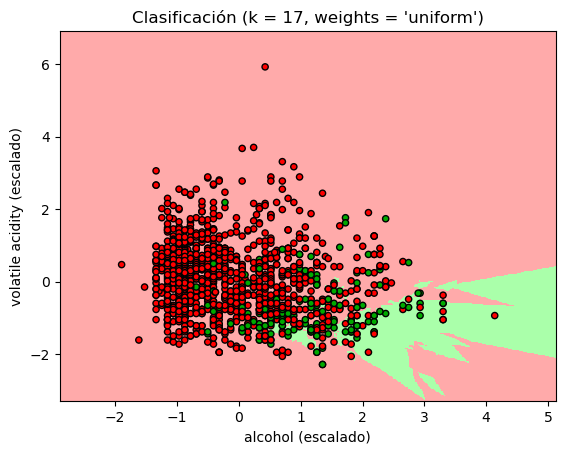

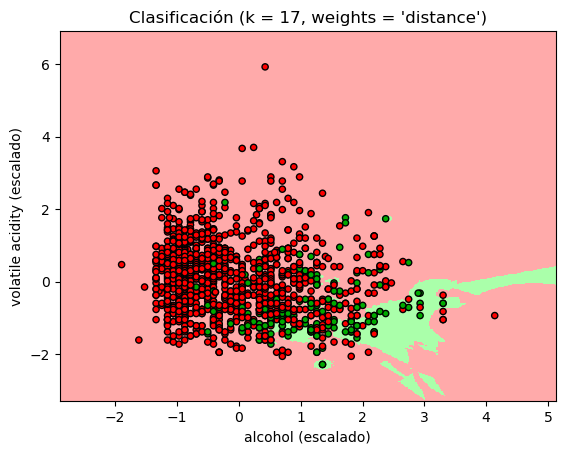

In [8]:
#  Mapa de colores para visualización
h = 0.02  # paso del mallado
cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA"])
cmap_bold  = ListedColormap(["#FF0000", "#00AA00"])
for weights in ["uniform", "distance"]:

    # Creamos una instancia del clasificador de vecinos más cercanos
    # y le pasamos los datos mediante fit().
    # El primer parámetro es con cuántos vecinos queremos clasificar
    # y el segundo el tipo de peso a utilizar.
    clf = neighbors.KNeighborsClassifier(n_neighbors, weights=weights)
    clf.fit(X_entrenamiento_sc, y_entrenamiento)

    # Establecemos los límites del gráfico y asignamos un color a cada punto de malla
    x_min, x_max = X_entrenamiento_sc[:, 0].min() - 1, X_entrenamiento_sc[:, 0].max() + 1
    y_min, y_max = X_entrenamiento_sc[:, 1].min() - 1, X_entrenamiento_sc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Agregamos el resultado al gráfico
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, shading="auto", cmap=cmap_light)

    # Ploteamos los datos de entrenamiento
    plt.scatter(X_entrenamiento_sc[:, 0], X_entrenamiento_sc[:, 1],
                c=y_entrenamiento, cmap=cmap_bold, edgecolor="k", s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Clasificación (k = %i, weights = '%s')" % (n_neighbors, weights))
    plt.xlabel("alcohol (escalado)")
    plt.ylabel("volatile acidity (escalado)")
    plt.show()




In [9]:
# -----------------------------------------------------------
# Predicción de nuevos datos (igual que el profe con Iris)
# -----------------------------------------------------------
# Ploteamos nuevos datos a clasificar (en escala original, luego escalamos)
Xn_original = np.array([[11.0, 0.35],   # debería ser "bueno"
                         [9.5,  0.65],   # debería ser "regular"
                         [12.5, 0.28]])  # debería ser "bueno"
Xn = scaler.transform(Xn_original)
Yn = clf.predict(Xn)
etiquetas = ["regular" if v == 0 else "bueno" for v in Yn]
print("Predicción de nuevos datos (KNN):")
for i, (alcohol, va) in enumerate(Xn_original):
    print(f"  alcohol={alcohol}, volatile acidity={va} => {etiquetas[i]}")


Predicción de nuevos datos (KNN):
  alcohol=11.0, volatile acidity=0.35 => regular
  alcohol=9.5, volatile acidity=0.65 => regular
  alcohol=12.5, volatile acidity=0.28 => bueno


In [10]:
knn = KNeighborsClassifier(n_neighbors=17, weights='distance')


knn.fit(X_entrenamiento_sc, y_entrenamiento)
y_pred_knn = knn.predict(X_test_sc)

print("Métricas KNN:")
print(classification_report(y_test, y_pred_knn, target_names=["Regular", "Bueno"]))


Métricas KNN:
              precision    recall  f1-score   support

     Regular       0.92      0.96      0.94       277
       Bueno       0.65      0.47      0.54        43

    accuracy                           0.89       320
   macro avg       0.78      0.71      0.74       320
weighted avg       0.88      0.89      0.89       320



## Árbol de Decisión

In [11]:
tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
tree.fit(X_entrenamiento, y_entrenamiento)
y_pred_tree = tree.predict(X_test)

print("Métricas Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree, target_names=["Regular", "Bueno"]))


Métricas Árbol de Decisión:
              precision    recall  f1-score   support

     Regular       0.89      0.99      0.94       277
       Bueno       0.77      0.23      0.36        43

    accuracy                           0.89       320
   macro avg       0.83      0.61      0.65       320
weighted avg       0.88      0.89      0.86       320



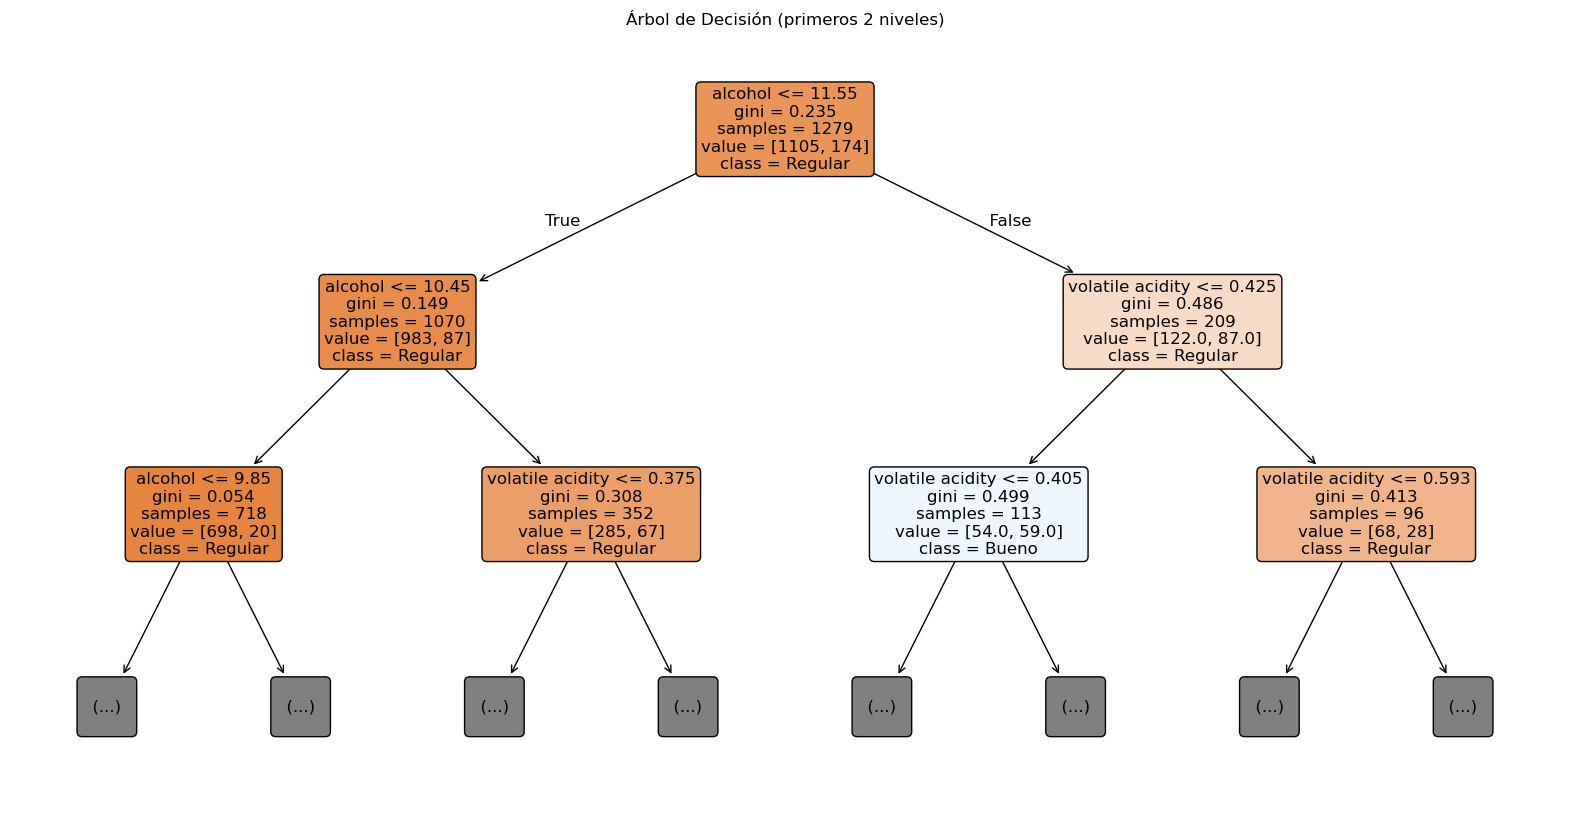

In [12]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=["alcohol", "volatile acidity"],
    class_names=["Regular", "Bueno"],
    filled=True,
    rounded=True,
    max_depth=2,        # muestra solo los primeros 2 niveles
    fontsize=12
)
plt.title("Árbol de Decisión (primeros 2 niveles)")
plt.show()

Accuracy KNN: 0.89375
Accuracy Árbol: 0.8875


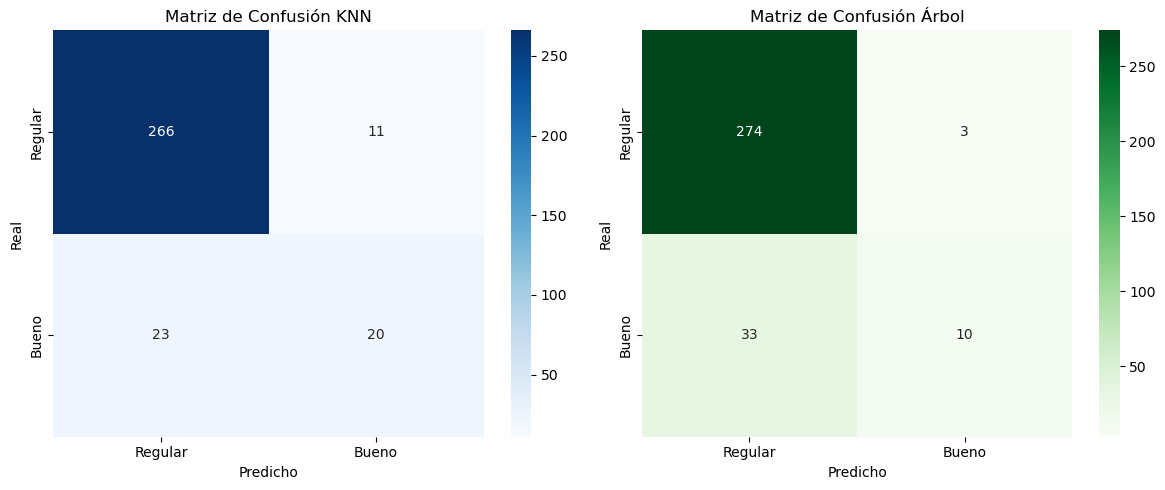

In [13]:
print("Accuracy KNN:", accuracy_score(y_test, y_pred_knn))
print("Accuracy Árbol:", accuracy_score(y_test, y_pred_tree))

etiquetas = ["Regular", "Bueno"]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", ax=ax[0], cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas)
ax[0].set_title("Matriz de Confusión KNN")
ax[0].set_xlabel("Predicho")
ax[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt="d", ax=ax[1], cmap="Greens",
            xticklabels=etiquetas, yticklabels=etiquetas)
ax[1].set_title("Matriz de Confusión Árbol")
ax[1].set_xlabel("Predicho")
ax[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

## Conclusion

- Ambos modelos muestran buen desempeño en la clase mayoritaria (vinos "regulares"), pero tienen dificultades con la clase minoritaria ("buenos"), lo que refleja el desbalance de clases del dataset (≈86% regular vs ≈14% bueno).

- KNN alcanza levemente mejor accuracy, pero ambos modelos presentan bajo recall para la clase "bueno" — muchos vinos de calidad quedan sin detectar.
- El uso de solo 2 variables (por razones de visualización) limita la capacidad predictiva; usar todas las variables probablemente mejoraría las métricas.
- Una mejora natural sería aplicar técnicas de balanceo (class_weight) o probar más variables con el árbol de decisión.
